# 残差网络（Residual Networks）——原作业中文讲解与 PyTorch 实现

欢迎学习本周的残差网络作业！理论上，很深的网络可以表示复杂的函数，但实际训练往往很困难。ResNet 通过快捷连接，让更深的网络更容易优化。

本文件以 `Residual_Networks.ipynb` 的章节顺序为主，结合 `Residual_Networks_v2a.ipynb` 的分阶段实现，翻译并展开原作业的核心说明。保留原图和三个练习；代码提供完整的 PyTorch 参考答案。建议先读每个练习前的步骤，自己口述数据如何流动，再运行代码。

完成后，你应能够：

- 实现恒等块（Identity Block）和卷积块（Convolutional Block）。
- 将它们组合成课程中的 ResNet-50，并训练 SIGNS 六分类模型。
- 解释快捷连接、逐元素相加，以及残差块为什么需要匹配尺寸。

**两个原版的差异如何处理？** 核心结构相同；旧版使用 `stage/block` 命名及 TensorFlow Session，新版增加 `training/initializer` 测试参数。这里使用 `nn.Module` 保存参数、`forward` 表示计算过程，用 `train()/eval()` 控制 BN。采用旧版的 Xavier 初始化思路，但不要求跨框架随机数或测试输出逐位相同。原版的 AutoGrader 标记、过时的运行时间和相互矛盾的准确率示例不作为本文件的运行要求。

目录：1 导入工具 → 2 深层网络的问题 → 3 构建残差块（练习 1、2）→ 4 ResNet-50（练习 3、数据、训练、评估、权重保存加载）→ 5 自己的图片 → 6 参考资料。

## 1 - 导入工具（Packages）

在安装了 `torch、numpy、h5py、Pillow、IPython` 的内核中，从上到下运行。下面先设置本机已验证的 MKL 兼容选项，再导入数值库。修改后首次运行请重启内核。

本文件不导入 TensorFlow，也不导入 Matplotlib。课程原图直接嵌入 Markdown，数据图片与曲线使用 PIL，避开此前卡住的 `canvas.print_png()`。

PyTorch 的图片张量是 **NCHW**：`(批次数, 通道数, 高, 宽)`；原版 Keras 使用 **NHWC**。后面所有尺寸示例均采用 NCHW。

In [1]:
import os
os.environ.setdefault("MKL_THREADING_LAYER", "SEQUENTIAL")

from pathlib import Path
import time
import random
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import h5py
from PIL import Image
from IPython.display import display, Image as PNGImage
from io import BytesIO

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "设备:", device, flush=True)

def find_resnets_dir():
    # 支持从本目录、Week 2 或项目根目录启动 Jupyter。
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / "ResNets",
                          base / "C4 - Convolutional Neural Networks/Week 2/ResNets"):
            if (candidate / "datasets/train_signs.h5").is_file() and (candidate / "datasets/test_signs.h5").is_file():
                return candidate
    raise FileNotFoundError("请从本项目内启动，确认 ResNets/datasets 中有两个 signs.h5 文件。")

RESNET_DIR = find_resnets_dir()
print("本作业目录:", RESNET_DIR, flush=True)

PyTorch: 2.7.1+cu118 设备: cuda
本作业目录: D:\ACMpractice\pytorch\learn_pytorch_WuEnDa\C4 - Convolutional Neural Networks\Week 2\ResNets


## 2 - 很深的神经网络面临的问题（The Problem of Very Deep Neural Networks）

上一周，我们学习了普通卷积网络。增加深度可以提高网络表达复杂函数的能力：靠近输入的浅层提取边缘等简单特征，靠近输出的深层组合出更复杂的形状或物体特征。

然而，层数增加并不保证训练效果改善。反向传播需要连续乘上各层的导数和权重，梯度可能迅速缩小，使浅层参数更新非常缓慢；也可能迅速增大，造成梯度爆炸。

![原作业图 1：梯度消失](images/vanishing_grad_kiank.png)

读图时关注浅层的梯度随训练变得很小这一现象。原文用它引出 ResNet；补充一点：深层网络还存在优化退化问题，即增加层数后训练误差反而上升，不能把所有困难都归结为梯度消失。

## 3 - 构建残差网络（Building a Residual Network）

在 ResNet 中，快捷连接（Shortcut / Skip Connection）让输入绕过若干层，直接参与后面的计算。

![原作业图 2：主路径与快捷连接](images/skip_connection_kiank.png)

左图只有主路径；右图额外把输入送到加法节点。主路径学习变换 $F(x)$，捷径传递 $x$，最后输出：

$$y=\operatorname{ReLU}(F(x)+x).$$

例如输入特征为 5，主路径学到修正量 −0.2，加法结果就是 4.8。网络学习的是对原特征的修正，不必每次都从头构造完整特征。

如果 $F(x)=0$，输出为 $\operatorname{ReLU}(x)$；本网络的块输入通常经过 ReLU、非负，因此此时可以原样传递输入。**对任意含负数的输入，不能直接说整个块都是恒等函数。**

忽略末尾 ReLU 的门控时，加法前输出的导数包含 $I+\partial F/\partial x$，为梯度提供直接路径。它改善优化，但不保证任何网络、任何设置都能训练成功。

下面学习两种残差块：尺寸一致用恒等捷径；尺寸不一致用带卷积的捷径。这里的“相加”是同位置数值相加，绝不是通道拼接。

### 3.1 - 恒等块（The Identity Block）

恒等块适用于输入与最终输出形状相同的情况。所谓“恒等”，指的是**快捷路径直接传递输入**，不是指主路径没有计算。

![原作业：跨越两个卷积层的恒等块](images/idblock2_kiank.png)

上图帮助理解捷径；本练习实际实现下图的三个卷积层版本：

![原作业：跨越三个卷积层的恒等块](images/idblock3_kiank.png)

按照原文，主路径分三步：

1. `1×1 CONV → BN → ReLU`：输出通道为 $F_1$，步幅 1，不补零。
2. `f×f CONV → BN → ReLU`：输出通道为 $F_2$，步幅 1，使用 SAME 保持高宽。本作业 $f=3$，对应 `padding=1`。
3. `1×1 CONV → BN`：输出通道为 $F_3$，步幅 1，**此处先不加 ReLU**。

最后把第三步输出与 `X_shortcut` 相加，再做 ReLU。

例如输入 `(N,256,8,8)`、`filters=[64,64,256]`：

| 位置 | 输出形状 | 作用 |
|---|---|---|
| 第一层 1×1 | `(N,64,8,8)` | 压缩通道 |
| 第二层 3×3 | `(N,64,8,8)` | 提取空间特征 |
| 第三层 1×1 | `(N,256,8,8)` | 恢复通道 |
| 捷径 | `(N,256,8,8)` | 原样传递 |
| 相加、ReLU | `(N,256,8,8)` | 合并原特征与修正量 |

这里的 `[64,64,256]` 是**三个卷积层各自的过滤器个数**，不是卷积核的高、宽、深。

### 练习 1 - identity_block

原版函数接收张量 `X`，用 Keras Functional API 构建网络。PyTorch 分两步：先创建 `block = IdentityBlock(...)`，再计算 `block(X)`。`__init__` 创建并保存层，`forward` 描述层的执行顺序；不要在 `forward` 内重新创建卷积层，否则参数不能被持续训练。

下面保留三段主路径的逐行写法。卷积使用 `bias=True`，与原作业默认设置相同。初始化采用 v2a 的 Glorot/Xavier 思路，BN 使用 PyTorch 默认设置。不同框架的 BN 默认参数、随机数和统计细节不同，因此不会复现原版的固定小数输出。

In [2]:
def initialize_weights(layer):
    # Glorot uniform 在 PyTorch 中称为 Xavier uniform。
    if isinstance(layer, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(layer.weight)
        if layer.bias is not None:
            nn.init.zeros_(layer.bias)
    elif isinstance(layer, nn.BatchNorm2d):
        nn.init.ones_(layer.weight)   # gamma = 1
        nn.init.zeros_(layer.bias)   # beta = 0

class IdentityBlock(nn.Module):
    def __init__(self, in_channels, f, filters):
        super().__init__()
        F1, F2, F3 = filters
        if in_channels != F3:
            raise ValueError("恒等块要求输入通道数等于 F3，才能和捷径相加。")
        if f < 1 or f % 2 == 0:
            raise ValueError("本教学实现使用正奇数 f，以对称 padding 保持尺寸。")

        # 第一段：1×1 卷积调整通道；步幅 1 保持高宽。
        self.conv1 = nn.Conv2d(in_channels, F1, kernel_size=1, stride=1)
        self.bn1 = nn.BatchNorm2d(F1)

        # 第二段：本作业 f=3，padding=1 对应原版 SAME。
        self.conv2 = nn.Conv2d(F1, F2, kernel_size=f, stride=1, padding=f // 2)
        self.bn2 = nn.BatchNorm2d(F2)

        # 第三段：恢复到 F3 个通道，先不激活。
        self.conv3 = nn.Conv2d(F2, F3, kernel_size=1, stride=1)
        self.bn3 = nn.BatchNorm2d(F3)
        self.relu = nn.ReLU()
        self.apply(initialize_weights)

    def forward(self, X):
        X_shortcut = X                   # 保存原输入，捷径不经过任何层。

        X = self.conv1(X)                # 主路径第一段
        X = self.bn1(X)
        X = self.relu(X)

        X = self.conv2(X)                # 主路径第二段
        X = self.bn2(X)
        X = self.relu(X)

        X = self.conv3(X)                # 主路径第三段
        X = self.bn3(X)                  # 注意：这里不调用 ReLU。

        assert X.shape == X_shortcut.shape
        X = X + X_shortcut               # 对应原版 Add()，逐元素相加。
        X = self.relu(X)                 # 相加之后再激活。
        return X

# 保留原练习名；这里返回可重复使用、可训练的模块。
def identity_block(in_channels, f, filters):
    return IdentityBlock(in_channels, f, filters)

先做小测试，再去拼完整网络。下面沿用原版“输入小张量、检查输出”的位置，用形状断言和恒等性质代替 TensorFlow 的固定数值测试。

`eval()` 让 BN 使用运行统计量；`no_grad()` 关闭梯度记录。这两个操作作用不同。恒等性质测试使用独立的块，不会把后面正式模型的参数清零。

In [3]:
X = torch.randn(3, 6, 4, 4)  # 原版 NHWC (3,4,4,6) 改成 NCHW。
block = identity_block(6, f=3, filters=[2, 4, 6]).eval()
with torch.no_grad():
    Y = block(X)
assert Y.shape == X.shape
print("恒等块输入/输出:", tuple(X.shape), tuple(Y.shape))

# 最后一个 BN 的 gamma、beta 都为 0，则主路径最终输出严格为 0。
zero_block = identity_block(6, 3, [2, 4, 6]).eval()
with torch.no_grad():
    zero_block.bn3.weight.zero_()
    zero_block.bn3.bias.zero_()
    positive_X = torch.rand(3, 6, 4, 4)
    torch.testing.assert_close(zero_block(positive_X), positive_X)
print("通过：主路径为零且输入非负时，整个块原样传递输入。")

# 对照原版 training=True/False：观察 BN 运行统计量是否更新。
before = block.bn1.running_mean.clone()
block.train()
with torch.no_grad():
    train_Y = block(X + 2)
assert not torch.equal(before, block.bn1.running_mean)
block.eval()
before_eval = block.bn1.running_mean.clone()
with torch.no_grad():
    eval_Y = block(X + 2)
torch.testing.assert_close(before_eval, block.bn1.running_mean)
print("通过：train 模式更新 BN 统计量，eval 模式保持统计量。")

恒等块输入/输出: (3, 6, 4, 4) (3, 6, 4, 4)
通过：主路径为零且输入非负时，整个块原样传递输入。
通过：train 模式更新 BN 统计量，eval 模式保持统计量。


### 3.2 - 卷积块（The Convolutional Block）

当输入与输出尺寸不同时，直接相加就会失败。原文的卷积块在快捷路径上添加 `1×1 CONV → BN`，把捷径调整到主路径输出的形状。

![原作业：卷积块](images/convblock_kiank.png)

与恒等块相比，原文强调的变化是：

1. 主路径第一层 `1×1` 卷积的步幅改为 $s$。
2. 主路径第二、三层仍为步幅 1，第三层 BN 后不加 ReLU。
3. 捷径使用 $F_3$ 个 `1×1` 过滤器，步幅也为 $s$，然后 BN；相加前捷径不单独做 ReLU。
4. 两路相加，再统一做 ReLU。

例如 `(N,256,8,8)` 经 `filters=[128,128,512], s=2`：主路径变为 `(N,128,4,4) → (N,128,4,4) → (N,512,4,4)`；捷径直接变成 `(N,512,4,4)`。

**1×1 卷积什么时候能缩小高宽？** 步幅 1 时保持高宽；这里步幅为 2，所以能够下采样。卷积块也可以取 `s=1`，只改变通道数——Stage 2 就是这种情况。

### 练习 2 - convolutional_block

请对照恒等块，找出下面的 `stride=s`、`shortcut_conv` 和 `shortcut_bn`。其余主路径顺序保持一致。

In [4]:
class ConvolutionalBlock(nn.Module):
    def __init__(self, in_channels, f, filters, s=2):
        super().__init__()
        F1, F2, F3 = filters
        if f < 1 or f % 2 == 0 or s < 1:
            raise ValueError("要求 f 为正奇数，s 为正整数。")
        # 主路径：只有第一个 1×1 卷积负责下采样。
        self.conv1 = nn.Conv2d(in_channels, F1, kernel_size=1, stride=s)
        self.bn1 = nn.BatchNorm2d(F1)
        self.conv2 = nn.Conv2d(F1, F2, kernel_size=f, stride=1, padding=f // 2)
        self.bn2 = nn.BatchNorm2d(F2)
        self.conv3 = nn.Conv2d(F2, F3, kernel_size=1, stride=1)
        self.bn3 = nn.BatchNorm2d(F3)

        # 捷径：同时匹配主路径最终的通道数与空间尺寸。
        self.shortcut_conv = nn.Conv2d(in_channels, F3, kernel_size=1, stride=s)
        self.shortcut_bn = nn.BatchNorm2d(F3)
        self.relu = nn.ReLU()
        self.apply(initialize_weights)

    def forward(self, X):
        X_shortcut = X

        X = self.conv1(X)
        X = self.bn1(X)
        X = self.relu(X)

        X = self.conv2(X)
        X = self.bn2(X)
        X = self.relu(X)

        X = self.conv3(X)
        X = self.bn3(X)

        X_shortcut = self.shortcut_conv(X_shortcut)
        X_shortcut = self.shortcut_bn(X_shortcut)

        assert X.shape == X_shortcut.shape
        X = X + X_shortcut
        return self.relu(X)

def convolutional_block(in_channels, f, filters, s=2):
    return ConvolutionalBlock(in_channels, f, filters, s)

In [5]:
X = torch.randn(3, 6, 4, 4)
block = convolutional_block(6, f=3, filters=[2, 4, 8], s=2).eval()
with torch.no_grad():
    Y = block(X)
assert Y.shape == (3, 8, 2, 2)
print("卷积块 s=2:", tuple(X.shape), "->", tuple(Y.shape))

# s=1 时只改变通道数，不缩小高宽。
block_s1 = convolutional_block(6, 3, [2, 4, 8], s=1).eval()
with torch.no_grad():
    assert block_s1(X).shape == (3, 8, 4, 4)
print("通过：s=1 保持高宽，s=2 将此例高宽减半。")

卷积块 s=2: (3, 6, 4, 4) -> (3, 8, 2, 2)
通过：s=1 保持高宽，s=2 将此例高宽减半。


## 4 - 构建第一个 ResNet 模型：50 层（Building Your First ResNet Model）

现在已有两个积木，可以按原图搭建整张网络。图中的 `ID BLOCK ×3` 表示串联三个独立的恒等块，各自拥有参数。

![原作业：ResNet-50 结构](images/resnet_kiank.png)

下面把 Stage 2 的卷积块与恒等块展开。每个块的主路径都有三个独立卷积层；BN 和 ReLU 不改变形状，但会改变数值。蓝色块的捷径用卷积把 64 通道调整为 256；红色块的捷径原样传递输入。

![残差块内部展开图](images/resnet_blocks_expanded_zh.png)

图中 AvgPool 的全局平均描述针对本作业的 64×64 输入：Stage 5 输出 2×2，代码的固定 2×2 平均池化恰好覆盖整个空间；代码并没有改成自适应全局池化。

**简化数值例子（只解释残差相加，不是完整卷积手算）：** 假设输入特征为 `[2,4]`，第一个恒等块主路径的三个卷积层及 BN/激活合起来算出修正量 `[1,-1]`。捷径保留 `[2,4]`，相加并 ReLU 后得到 `[3,3]`。第二个恒等块接收 `[3,3]`，如果它的主路径算出 `[0.5,1]`，最终得到 `[3.5,4]`。前后都只有两个数，但内容不断变化；两个块各有独立参数。

以下逐项对应原版架构，输入为 `(N,3,64,64)`：

| 阶段 | 原作业要求 | 输出 `(C,H,W)` |
|---|---|---|
| 补零 | 四周各补 3 | `(3,70,70)` |
| Stage 1 | 64 个 7×7 卷积，步幅 2；BN、ReLU；3×3 最大池化，步幅 2 | `(64,15,15)` |
| Stage 2 | 卷积块 `[64,64,256], s=1`；2 个恒等块 | `(256,15,15)` |
| Stage 3 | 卷积块 `[128,128,512], s=2`；3 个恒等块 | `(512,8,8)` |
| Stage 4 | 卷积块 `[256,256,1024], s=2`；5 个恒等块 | `(1024,4,4)` |
| Stage 5 | 卷积块 `[512,512,2048], s=2`；2 个恒等块 | `(2048,2,2)` |
| 平均池化 | 2×2，步幅 2 | `(2048,1,1)` |
| 展平与分类 | 2048 个特征 → 6 个类别分数 | `(N,6)` |

为什么叫 50 层？按惯例数主路径上的带权重层：初始卷积 1 层，加上 $(3+4+6+3)\times3=48$ 个块内卷积，再加全连接层 1 层，共 50 层。捷径投影卷积不计入这个命名数字，BN 和激活也不计入。

尺寸公式（本作业 dilation=1）：

$$H_{out}=\left\lfloor\frac{H_{in}+2p-f}{s}\right\rfloor+1.$$

例如初始卷积 $(70-7)//2+1=32$，池化 $(32-3)//2+1=15$；Stage 3 的 1×1 下采样是 $(15-1)//2+1=8$，不是 7。

普通卷积含偏置参数量为 $(f^2C_{in}+1)C_{out}$；BN 的可训练参数为 $2C_{out}$；全连接参数量为 $(n_{in}+1)n_{out}$。BN 的运行均值、方差是缓冲量，不算可训练参数。

### 练习 3 - ResNet50

下面像原版一样显式列出 Stage 2～5 的每个块。`stage2` 相当于旧版的 2a/2b/2c，模块内的三个位置依次对应这些块。我们使用原版固定的 2×2 平均池化，所以本实现约定输入就是 64×64。

原版结尾为 Dense + Softmax；这里用 Linear 输出 logits，直接交给 `CrossEntropyLoss`，预测概率时再 Softmax。此模型保留课程的下采样位置与池化方式，不直接加载 torchvision 的 ResNet 权重。

In [6]:
class ResNet50(nn.Module):
    def __init__(self, input_shape=(3, 64, 64), classes=6):
        super().__init__()
        if tuple(input_shape) != (3, 64, 64):
            raise ValueError("本作业输入形状应为 PyTorch 的 (3,64,64)。")
        self.pad = nn.ZeroPad2d(3)
        self.stage1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.stage2 = nn.Sequential(
            convolutional_block(64, 3, [64, 64, 256], s=1),   # 2a
            identity_block(256, 3, [64, 64, 256]),            # 2b
            identity_block(256, 3, [64, 64, 256]),            # 2c
        )
        self.stage3 = nn.Sequential(
            convolutional_block(256, 3, [128, 128, 512], s=2),
            identity_block(512, 3, [128, 128, 512]),
            identity_block(512, 3, [128, 128, 512]),
            identity_block(512, 3, [128, 128, 512]),
        )
        self.stage4 = nn.Sequential(
            convolutional_block(512, 3, [256, 256, 1024], s=2),
            identity_block(1024, 3, [256, 256, 1024]),
            identity_block(1024, 3, [256, 256, 1024]),
            identity_block(1024, 3, [256, 256, 1024]),
            identity_block(1024, 3, [256, 256, 1024]),
            identity_block(1024, 3, [256, 256, 1024]),
        )
        self.stage5 = nn.Sequential(
            convolutional_block(1024, 3, [512, 512, 2048], s=2),
            identity_block(2048, 3, [512, 512, 2048]),
            identity_block(2048, 3, [512, 512, 2048]),
        )
        self.avgpool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(2048, classes)
        # 残差块已经初始化；这里初始化开头和分类头。
        self.stage1.apply(initialize_weights)
        self.fc.apply(initialize_weights)

    def forward(self, X):
        if tuple(X.shape[1:]) != (3, 64, 64):
            raise ValueError(f"期望 (N,3,64,64)，实际为 {tuple(X.shape)}")
        X = self.pad(X)
        X = self.stage1(X)
        X = self.stage2(X)
        X = self.stage3(X)
        X = self.stage4(X)
        X = self.stage5(X)
        X = self.avgpool(X)
        X = self.flatten(X)
        return self.fc(X)  # logits，训练时不做 Softmax。

In [7]:
model = ResNet50(input_shape=(3, 64, 64), classes=6).to(device)
print("可训练参数:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# 对应原版 model.summary() / 结构检查：逐阶段打印尺寸，避免输出几百行。
model.eval()  # 模拟输入不能污染 BN 运行统计量。
with torch.no_grad():
    X = torch.zeros(2, 3, 64, 64, device=device)
    for name in ("pad", "stage1", "stage2", "stage3", "stage4", "stage5", "avgpool", "flatten", "fc"):
        X = getattr(model, name)(X)
        print(f"{name:10s}: {tuple(X.shape)}")
    assert model(torch.zeros(2, 3, 64, 64, device=device)).shape == (2, 6)

可训练参数: 23546886
pad       : (2, 3, 70, 70)
stage1    : (2, 64, 15, 15)
stage2    : (2, 256, 15, 15)
stage3    : (2, 512, 8, 8)
stage4    : (2, 1024, 4, 4)
stage5    : (2, 2048, 2, 2)
avgpool   : (2, 2048, 1, 1)
flatten   : (2, 2048)
fc        : (2, 6)


### 4.1 - 配置学习过程：对应原版 model.compile

模型结构准备好后，原作业先配置 Adam、交叉熵和准确率。PyTorch 不需要 `compile()` 来完成这一步：显式创建损失函数和优化器，在训练循环中计算准确率。

六分类要求模型输出 `(N,6)`，标签为 `(N,)` 的 `torch.long` 整数 0～5。不要使用二分类 BCE，也不需要原版的 one-hot 编码。优化器必须绑定当前模型的参数；重新创建模型后应重新创建优化器。

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

### 4.2 - 加载 SIGNS 数据集

模型准备好后，原作业加载熟悉的 SIGNS 数据集：六类图片分别表示手语数字 0～5。

![原作业：SIGNS 数据集](images/signs_data_kiank.png)

本地 `ResNets/datasets/train_signs.h5` 包含 1080 张训练图片，`test_signs.h5` 包含 120 张测试图片；图片是 `(64,64,3)` 的 uint8，标签已经是整数。下面直接用 h5py 读取当前目录的数据，不调用依赖 TensorFlow 的原版工具函数。

与原版一样，图片除以 255 归一化。额外从训练文件按类别各划出 20% 作为验证集：864 张用于参数更新，216 张用于每轮验证；120 张测试图片留到最后评估。这是明确添加的学习辅助，避免每轮拿测试集调参。Windows 下 `num_workers=0`，减少 notebook 多进程读取问题。

训练/验证/测试: 864 216 120
图片: torch.Size([1080, 3, 64, 64]) torch.float32 标签: torch.Size([1080]) torch.int64


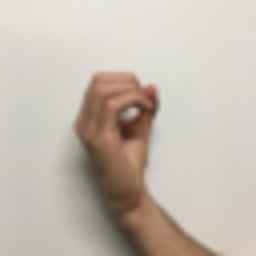

此图对应的手语数字: 0


In [9]:
with h5py.File(RESNET_DIR / "datasets/train_signs.h5", "r") as f:
    X_train_orig = f["train_set_x"][:]
    Y_train_orig = f["train_set_y"][:].reshape(-1)
    classes = f["list_classes"][:]
with h5py.File(RESNET_DIR / "datasets/test_signs.h5", "r") as f:
    X_test_orig = f["test_set_x"][:]
    Y_test_orig = f["test_set_y"][:].reshape(-1)
    assert np.array_equal(classes, f["list_classes"][:])

assert np.array_equal(classes, np.arange(6))
assert X_train_orig.shape[1:] == X_test_orig.shape[1:] == (64, 64, 3)
assert set(Y_train_orig.tolist()) == set(range(6))
assert set(Y_test_orig.tolist()) <= set(range(6))

def image_tensor(images):
    # NHWC -> NCHW，并将 0~255 的整数转换为 0~1 的 float32。
    return torch.from_numpy(images).permute(0, 3, 1, 2).contiguous().float() / 255.0

X_train = image_tensor(X_train_orig)
X_test = image_tensor(X_test_orig)
Y_train = torch.from_numpy(Y_train_orig).long()
Y_test = torch.from_numpy(Y_test_orig).long()

rng = np.random.default_rng(SEED)
train_indices, val_indices = [], []
for label in classes:
    indices = np.flatnonzero(Y_train_orig == label)
    rng.shuffle(indices)
    n_val = max(1, round(len(indices) * 0.2))
    val_indices.extend(indices[:n_val].tolist())
    train_indices.extend(indices[n_val:].tolist())
assert not set(train_indices) & set(val_indices)
assert len(train_indices) + len(val_indices) == len(Y_train)

BATCH_SIZE = 16  # 原版使用 32；这里减小以降低 ResNet-50 的显存占用。
train_loader = DataLoader(TensorDataset(X_train[train_indices], Y_train[train_indices]),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(TensorDataset(X_train[val_indices], Y_train[val_indices]),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(TensorDataset(X_test, Y_test),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("训练/验证/测试:", len(train_indices), len(val_indices), len(Y_test))
print("图片:", X_train.shape, X_train.dtype, "标签:", Y_train.shape, Y_train.dtype)

index = 124
display(Image.fromarray(X_train_orig[index]).resize((256, 256)))
print("此图对应的手语数字:", int(Y_train_orig[index]))

### 4.3 - 训练模型：对应原版 model.fit

原版用一行 `model.fit(...)` 隐藏了训练细节。下面把同一过程展开：取一个 batch → 前向计算 → 计算损失 → 清空旧梯度 → 反向传播 → 更新参数。

`run_epoch` 负责一遍数据：传入优化器时训练，不传时评估。训练使用 `model.train()` 更新 BN 统计量；评估使用 `model.eval()` 和关闭梯度记录。每轮开始、首个 batch 和每 10 个 batch 都打印进度，因此可以区分“正在训练”和“卡在别的地方”。损失按样本数加权平均，末尾的小 batch 不会被错误地等权平均。

In [10]:
def run_epoch(model, loader, criterion, optimizer=None, label="评估"):
    training = optimizer is not None
    model.train(training)
    total_loss, total_correct, total = 0.0, 0, 0
    start = time.perf_counter()
    print(f"[{label}] 开始，共 {len(loader)} 个 batch", flush=True)
    with torch.set_grad_enabled(training):
        for step, (xb, yb) in enumerate(loader, start=1):
            xb, yb = xb.to(device), yb.to(device)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            if not torch.isfinite(loss).item():
                raise RuntimeError(f"{label} 第 {step} 个 batch 的损失不是有限数。")
            if training:
                loss.backward()
                optimizer.step()

            count = yb.size(0)
            total_loss += loss.item() * count
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total += count
            if step == 1 or step % 10 == 0 or step == len(loader):
                print(f"[{label}] batch {step}/{len(loader)}，"
                      f"累计 loss={total_loss / total:.4f}，"
                      f"耗时 {time.perf_counter() - start:.1f}s", flush=True)
    if total == 0:
        raise ValueError("数据加载器为空。")
    return total_loss / total, total_correct / total

def fit(model, train_loader, val_loader, criterion, optimizer, epochs=2):
    history = {key: [] for key in ("loss", "accuracy", "val_loss", "val_accuracy")}
    for epoch in range(1, epochs + 1):
        print(f"\n===== Epoch {epoch}/{epochs} =====", flush=True)
        loss, accuracy = run_epoch(model, train_loader, criterion, optimizer, label="训练")
        val_loss, val_accuracy = run_epoch(model, val_loader, criterion, label="验证")
        for key, value in zip(history, (loss, accuracy, val_loss, val_accuracy)):
            history[key].append(value)
        print(f"本轮完成：loss={loss:.4f}, accuracy={accuracy:.3f}, "
              f"val_loss={val_loss:.4f}, val_accuracy={val_accuracy:.3f}", flush=True)
    print("训练全部结束。", flush=True)
    return history

v2a 默认训练 2 轮，另一份原版的训练代码为 10 轮，但后面的文字仍有“两轮”的旧说明。这里先用 **2 轮**学习整个流程，后续可改为 10～20 轮观察验证集表现。ResNet-50 比上一份小模型大得多，CPU 训练可能明显更慢，具体耗时以 batch 日志为准。

下列单元返回后，`history` 才包含本次完整的训练记录。只训练两轮并不保证较高测试准确率；不同初始化、数据划分及 BN 设置也会影响结果。重复运行此训练单元会在当前权重上继续训练；要从零训练，重新运行创建模型和优化器的单元。

In [11]:
EPOCHS = 2
history = fit(model, train_loader, val_loader, criterion, optimizer, epochs=EPOCHS)


===== Epoch 1/2 =====
[训练] 开始，共 54 个 batch
[训练] batch 1/54，累计 loss=1.7246，耗时 0.6s
[训练] batch 10/54，累计 loss=2.9099，耗时 1.2s
[训练] batch 20/54，累计 loss=2.2267，耗时 1.8s
[训练] batch 30/54，累计 loss=2.0028，耗时 2.4s
[训练] batch 40/54，累计 loss=1.8277，耗时 3.0s
[训练] batch 50/54，累计 loss=1.6519，耗时 3.6s
[训练] batch 54/54，累计 loss=1.6107，耗时 3.9s
[验证] 开始，共 14 个 batch
[验证] batch 1/14，累计 loss=0.8137，耗时 0.0s
[验证] batch 10/14，累计 loss=2.8751，耗时 0.2s
[验证] batch 14/14，累计 loss=2.2592，耗时 0.3s
本轮完成：loss=1.6107, accuracy=0.484, val_loss=2.2592, val_accuracy=0.514

===== Epoch 2/2 =====
[训练] 开始，共 54 个 batch
[训练] batch 1/54，累计 loss=0.5307，耗时 0.1s
[训练] batch 10/54，累计 loss=0.7436，耗时 0.6s
[训练] batch 20/54，累计 loss=0.7414，耗时 1.2s
[训练] batch 30/54，累计 loss=0.7655，耗时 1.8s
[训练] batch 40/54，累计 loss=0.7608，耗时 2.4s
[训练] batch 50/54，累计 loss=0.7629，耗时 3.0s
[训练] batch 54/54，累计 loss=0.7755，耗时 3.3s
[验证] 开始，共 14 个 batch
[验证] batch 1/14，累计 loss=0.0016，耗时 0.0s
[验证] batch 10/14，累计 loss=1.3536，耗时 0.2s
[验证] batch 14/14，累计 loss=1.4938，耗时 0.2s
本轮完成

### 4.4 - 查看曲线和独立测试集结果

这一小节在原版评估步骤旁补充训练/验证曲线。下方绘图函数直接用 PIL 画线并编码 PNG，不调用 Matplotlib 或交互式绘图后端。它会打印“绘制、显示、完成”的状态，评估也会打印 batch 进度。

曲线只能反映已记录的训练结果，画图本身不会继续训练模型。蓝线为训练集、红线为验证集；测试集只在后面的 `run_epoch` 中评估。

In [12]:
def plot_history(history):
    """使用 PIL 绘制静态曲线，绕过本机 Matplotlib PNG 渲染卡顿。"""
    from PIL import ImageDraw
    import math
    import time

    started = time.perf_counter()
    for key, ylabel in (("loss", "Loss"), ("accuracy", "Accuracy")):
        print(f"[绘图] 开始绘制 {ylabel}……", flush=True)
        train = [float(v) for v in history[key]]
        validation = [float(v) for v in history["val_" + key]]
        if not train or not validation:
            print(f"[绘图] {ylabel} 无数据，跳过。", flush=True)
            continue
        values = train + validation
        if not all(math.isfinite(v) for v in values):
            raise ValueError(f"{ylabel} 中存在 NaN 或无穷大，请检查训练记录。")

        # PIL 直接绘制像素，不使用 Matplotlib、Agg 或 pyplot。
        picture = Image.new("RGB", (800, 450), "white")
        draw = ImageDraw.Draw(picture)
        left, top, right, bottom = 85, 55, 745, 380
        low, high = min(values), max(values)
        margin = max((high - low) * 0.1, 0.01)
        low, high = low - margin, high + margin
        count = max(len(train), len(validation))

        draw.text((left, 15), "Model " + ylabel, fill="black")
        draw.text((450, 15), "Train", fill="blue")
        draw.text((550, 15), "Validation", fill="red")
        draw.text((370, 420), "Epoch", fill="black")

        # 纵轴刻度与网格。
        for i in range(6):
            value = low + (high - low) * i / 5
            y = bottom - (bottom - top) * i / 5
            draw.line([(left, y), (right, y)], fill="#dddddd")
            draw.text((5, y - 5), f"{value:.3f}", fill="black")
        draw.line([(left, top), (left, bottom), (right, bottom)],
                  fill="black", width=2)

        # 最多显示 6 个 epoch 刻度；也支持只有一轮的记录。
        for index in sorted({round(i * (count - 1) / 5) for i in range(6)}):
            x = left + index / max(count - 1, 1) * (right - left)
            draw.text((x - 5, bottom + 10), str(index + 1), fill="black")

        for series, color in ((train, "blue"), (validation, "red")):
            points = [
                (left + i / max(count - 1, 1) * (right - left),
                 bottom - (value - low) / (high - low) * (bottom - top))
                for i, value in enumerate(series)
            ]
            if len(points) > 1:
                draw.line(points, fill=color, width=3)
            for x, y in points:
                draw.ellipse((x - 3, y - 3, x + 3, y + 3), fill=color)

        print(f"[绘图] {ylabel} 绘制完成，开始显示……", flush=True)
        # 显式编码 PNG，避免依赖交互式绘图后端。
        with BytesIO() as stream:
            picture.save(stream, format="PNG")
            display(PNGImage(data=stream.getvalue()))
        picture.close()
        print(f"[绘图] {ylabel} 显示调用完成。", flush=True)
    print(f"[绘图] 全部完成，用时 {time.perf_counter() - started:.2f} 秒。", flush=True)

[绘图] 开始绘制 Loss……
[绘图] Loss 绘制完成，开始显示……


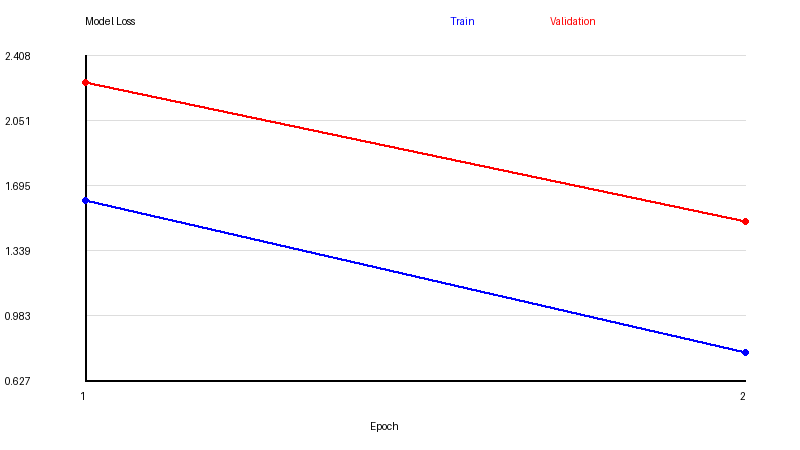

[绘图] Loss 显示调用完成。
[绘图] 开始绘制 Accuracy……
[绘图] Accuracy 绘制完成，开始显示……


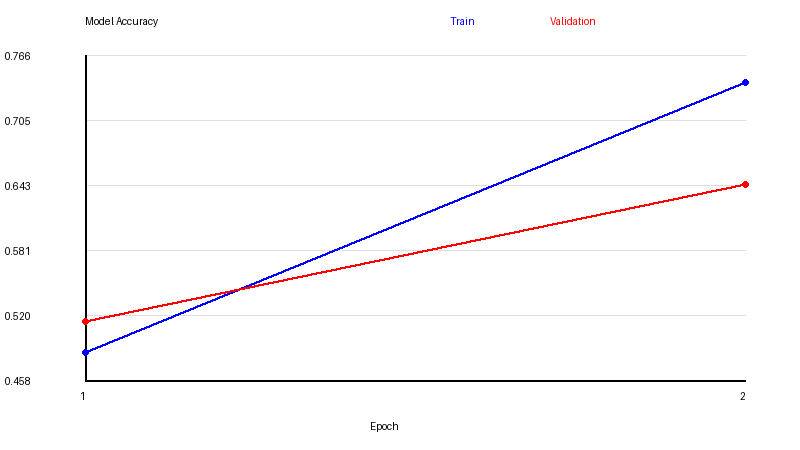

[绘图] Accuracy 显示调用完成。
[绘图] 全部完成，用时 0.02 秒。
[评估] 开始，共 8 个 batch
[评估] batch 1/8，累计 loss=0.2242，耗时 0.2s
[评估] batch 8/8，累计 loss=1.6462，耗时 0.3s
独立测试集：loss=1.6462, accuracy=0.692


In [13]:
plot_history(history)
test_loss, test_acc = run_epoch(model, test_loader, criterion)
print(f"独立测试集：loss={test_loss:.4f}, accuracy={test_acc:.3f}", flush=True)

### 4.5 - 更多训练，以及保存和加载训练好的模型

原版在这里加载课程提供的 `ResNet50.h5` / `resnet50.h5`，展示训练更久后的效果。它是 Keras 模型文件，不能交给 PyTorch 的 `load_state_dict` 直接使用；本文件也没有声称拥有对应的 PyTorch 预训练权重。

对应替代操作是保存自己的训练结果，再用同一网络结构加载。下面默认跳过文件写入；需要保存时把 `SAVE_MODEL` 改为 True。加载路径只指向本版本生成的权重文件；此前精简版的模块命名和偏置配置不同，其权重不直接兼容。保存的是模型权重和 BN 缓冲量，没有保存优化器状态，加载后若继续训练应新建优化器。

In [14]:
SAVE_MODEL = False
LOAD_MODEL = False
checkpoint_path = RESNET_DIR / "resnet50_course_zh_v2.pt"

if SAVE_MODEL:
    if checkpoint_path.exists():
        raise FileExistsError(f"文件已存在，请换一个文件名再保存：{checkpoint_path}")
    torch.save({"model_state_dict": model.state_dict(), "classes": classes.tolist()}, checkpoint_path)
    print("已保存:", checkpoint_path)

if LOAD_MODEL:
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    assert checkpoint["classes"] == classes.tolist()
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print("已加载权重；下面可用自己的图片测试。")

## 5 - 用自己的图片测试（可选，不评分）

原作业邀请你拍摄自己的手语图片，检查模型预测。将下面的 `MY_IMAGE` 改为图片路径，例如 `r"C:\Users\21467\Desktop\my_sign.jpg"`（实际路径中的反斜杠只需一个，也可使用正斜杠）。默认 None 会跳过，保证从头运行时不因个人图片不存在而中断。

处理顺序必须与训练一致：RGB → 64×64 → NCHW → float32 → 除以 255。不要使用 ImageNet 均值方差，因为本模型没有按那种方式训练。原 v2a 的更新记录特别修正了自定义图片归一化，这里保留这一点。

模型输出 6 个 logits，Softmax 将它们转为预测概率，最大者对应手语数字。此任务识别 0～5 的手势，不识别图片里的印刷数字；背景、光照或手势与训练集差异很大时，预测可能不可靠，概率也不是正确性的保证。

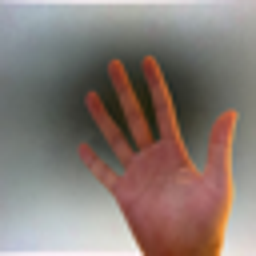

预测手语数字: 0
数字 0: 99.85%
数字 1: 0.00%
数字 2: 0.00%
数字 3: 0.13%
数字 4: 0.01%
数字 5: 0.00%


In [19]:
MY_IMAGE = "MyDataset/5.jpg"  # 例如 r"C:\Users\21467\Desktop\my_sign.jpg"
if MY_IMAGE is not None:
    with Image.open(MY_IMAGE) as source:
        image = source.convert("RGB").resize((64, 64))
    x = torch.from_numpy(np.array(image)).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    model.eval()
    with torch.no_grad():
        probabilities = model(x.to(device)).softmax(dim=1)[0].cpu()
    display(image.resize((256, 256)))
    predicted_index = probabilities.argmax().item()
    print("预测手语数字:", int(classes[predicted_index]))
    for label, probability in zip(classes, probabilities.tolist()):
        print(f"数字 {label}: {probability:.2%}")
else:
    print("未设置个人图片，跳过此可选步骤。")

### 回顾原作业希望你掌握的内容

- 深层网络表达能力强，但优化可能更困难；快捷连接为信息与梯度提供直接路径。
- 恒等块的捷径原样通过，要求相加的形状相同；卷积块在捷径中使用卷积匹配形状。
- 主路径第三个 BN 后不立即 ReLU，而是在主路径与捷径相加后再激活。
- 用两种块按 `[3,4,6,3]` 的数量组合，就得到本作业的 ResNet-50。

检验理解：输入 `(N,256,8,8)` 时，为什么 `IdentityBlock(256,3,[64,64,128])` 不成立？答：主路径最终有 128 个通道，而捷径有 256 个，无法逐元素相加。换成卷积块可以投影捷径来匹配。

原 v2a 最后的 Graphviz 网络绘图，这里由前面的原版结构图与逐阶段尺寸打印替代。需要查看每个具体层时，可单独运行 `print(model)`，无需安装 Graphviz。

## 6 - 参考资料（Bibliography）

本中文改编的直接依据为同目录 `Residual_Networks.ipynb` 与 `Residual_Networks_v2a.ipynb`；插图沿用它们的 `images` 资源。新增内容包括 PyTorch 对应解释、尺寸推导、独立验证集、训练进度和 PIL 绘图。

- Kaiming He 等：Deep Residual Learning for Image Recognition，2015（原作业引用的 ResNet 论文）。
- François Chollet：deep-learning-models 中的 ResNet50 实现（原作业列出的实现参考）。

本文件用于理解和本地学习，不是原 TensorFlow 自动评分器的提交文件。